In [1]:
# 6.6 Q2 - Disease Susceptibility Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
    classification_report, roc_curve, auc)

In [3]:
df = pd.read_csv('datasets/medical_disease.csv')
print("Shape:", df.shape)
print(df.head())
print()
print("Class distribution:")
print(df['disease'].value_counts())

Shape: (500, 8)
   age  gender   bmi  blood_pressure  cholesterol  smoker  exercise  disease
0   63       0  39.3             128          198       1         0        1
1   76       0  19.9             135          269       0         1        0
2   53       1  35.4             118          193       0         1        0
3   39       1  31.0             151          205       1         0        1
4   67       1  28.6             151          260       0         1        1

Class distribution:
disease
0    272
1    228
Name: count, dtype: int64


In [4]:
print("Null values:")
print(df.isnull().sum())

Null values:
age               0
gender            0
bmi               0
blood_pressure    0
cholesterol       0
smoker            0
exercise          0
disease           0
dtype: int64


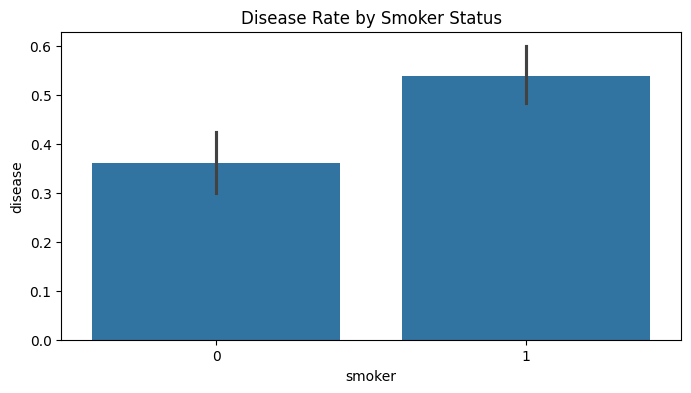

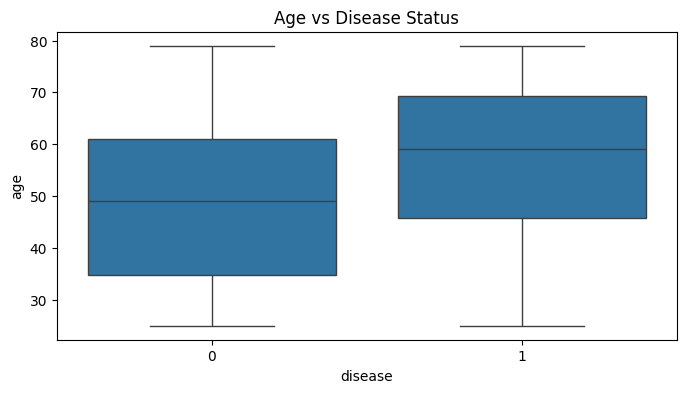

In [5]:
plt.figure(figsize=(8, 4))
sns.barplot(x='smoker', y='disease', data=df)
plt.title('Disease Rate by Smoker Status')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x='disease', y='age', data=df)
plt.title('Age vs Disease Status')
plt.show()

In [6]:
# One-hot encode gender

In [7]:
df_model = pd.get_dummies(df, columns=['gender'], drop_first=True)
print("Columns:", list(df_model.columns))

y = df_model['disease']
X = df_model.drop(columns=['disease'])
print("X shape:", X.shape, "y shape:", y.shape)

Columns: ['age', 'bmi', 'blood_pressure', 'cholesterol', 'smoker', 'exercise', 'disease', 'gender_1']
X shape: (500, 7) y shape: (500,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (350, 7) Test: (150, 7)


In [9]:
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)

model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

print("Coefficients:")
for n, c in zip(X.columns, model.coef_[0]):
    print("  " + n.ljust(15), round(c, 4))

Coefficients:
  age             0.8033
  bmi             0.6886
  blood_pressure  0.4625
  cholesterol     0.7823
  smoker          0.5762
  exercise        0.3625
  gender_1        0.2103


In [10]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[63 19]
 [20 48]]
Accuracy: 0.74

              precision    recall  f1-score   support

           0       0.76      0.77      0.76        82
           1       0.72      0.71      0.71        68

    accuracy                           0.74       150
   macro avg       0.74      0.74      0.74       150
weighted avg       0.74      0.74      0.74       150



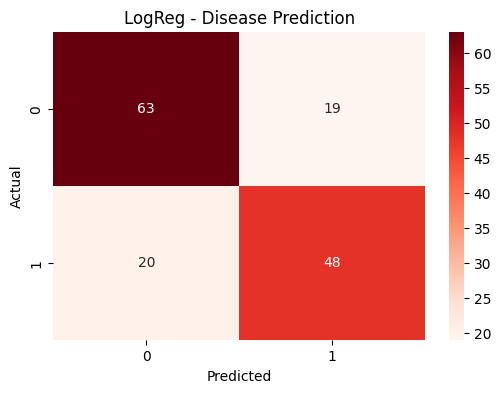

In [11]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LogReg - Disease Prediction')
plt.show()

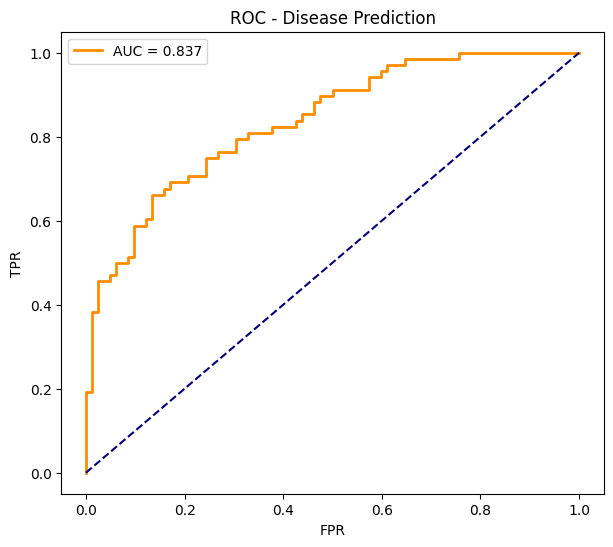

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='AUC = %.3f' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC - Disease Prediction')
plt.legend()
plt.show()